<a href="https://colab.research.google.com/github/bwecworkshop-dot/eventapplication/blob/main/stick_price_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving stock_data.csv to stock_data.csv
User uploaded file "stock_data.csv" with length 37728 bytes


In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv("stock_data.csv")

print(data.head())

In [3]:
# Shape and columns
print(data.shape)
print(data.columns)

# Data info
print(data.info())

# Statistical summary
print(data.describe())

(365, 6)
Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB
None
          Stock_1     Stock_2     Stock_3     Stock_4     Stock_5
count  365.000000  365.000000  365.000000  365.000000  365.000000
mean   107.772577   81.105216   94.519502  117.407560  106.866865
std      7.398296   11.435212    6.519213    6.778527    3.760968
min     91.474442   62.414219   81.111434   99.909756   99.833309
25%    101.603117   69.328263   89.788068  112.209912  103.927072
50%    107.4

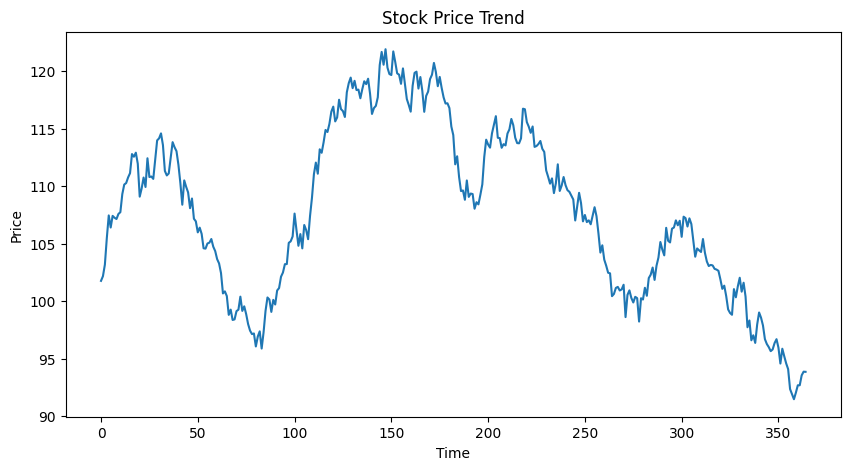

In [4]:
import matplotlib.pyplot as plt

# Plot one stock column (example: Stock_1)
plt.figure(figsize=(10,5))
plt.plot(data['Stock_1'])
plt.title("Stock Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [5]:
# Handle missing values
print(data.isnull().sum())
data.fillna(method='ffill', inplace=True)

# Remove duplicates
data.drop_duplicates(inplace=True)

# Use only one stock for prediction
data = data[['Stock_1']]

Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64


/tmp/ipykernel_8325/44511754.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (305, 60, 1)
y shape: (305, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.1214
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0361
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0282
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0249
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0190
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0148
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0131
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0134
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0118
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0116
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0117
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0102
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.0115
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0092
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0099


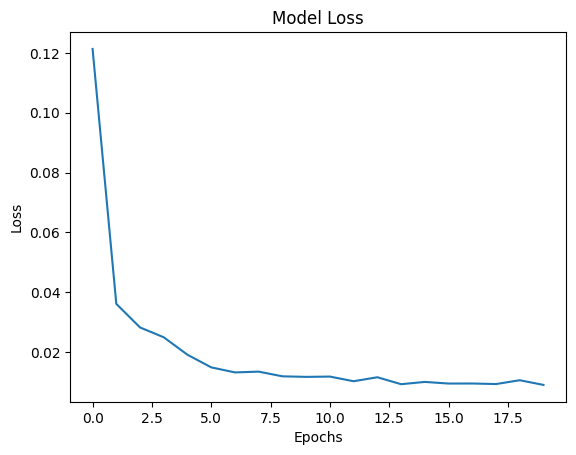

In [10]:
# Train model
history = model.fit(X, y, epochs=20, batch_size=32)

# Plot loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [13]:
# You can further tune:
# epochs = 30
# batch_size = 16

In [ ]:
from flask import Flask

app = Flask(__name__)

@app.route('/')
def home():
    return "Stock Price Prediction App Running!"

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
# Predictions
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)

# Plot results
plt.plot(data.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()